# TEST PID FMU

In [88]:
from path import Path

root = Path(r'/home/flo/repos/SystemSimulation/demos/ControlledPendulum/')
pkg_dir = Path(root / "ControlledPendulum")
pkg_str = str(root / "ControlledPendulum" / "package.mo")
pkg_name = "ControlledPendulum"

model_name = "PID_Cont"

from OMPython import ModelicaSystem
import shutil

def create_modelica_system(model_name):
    model = ModelicaSystem(pkg_str, model_name)
    return model

def create_fmu(model: ModelicaSystem, fmuType="cs"):
    model.buildModel()
    fmu_path = model.convertMo2Fmu(fmuType=fmuType)
    print(fmu_path)
    return fmu_path

def move_file(src_path, dst_path):
    shutil.move(src_path, dst_path)

from pyfmi import load_fmu

model = create_modelica_system(f"{pkg_name}.{model_name}")

fmu_path = create_fmu(model, fmuType="cs")

dst_path = str(root / "FMUs" / f"{model_name}.fmu")
move_file(fmu_path, dst_path)

fmu_paths = {model_name: dst_path}

pid = load_fmu(fmu_paths[model_name])


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


/tmp/tmp1yft0mnn/ControlledPendulum.PID_Cont.fmu


In [106]:
pid.get_categories()

[b'logEvents',
 b'logSingularLinearSystems',
 b'logNonlinearSystems',
 b'logDynamicStateSelection',
 b'logStatusWarning',
 b'logStatusDiscard',
 b'logStatusError',
 b'logStatusFatal',
 b'logStatusPending',
 b'logAll',
 b'logFmi2Call']

In [89]:
# (Optional but clear) explicit init
pid.setup_experiment(start_time=0.0)
pid.enter_initialization_mode()
pid.set('uMin', -1); pid.set('uMax', 1)
pid.exit_initialization_mode()

t = 0.0
dt = 0.01  # must match the Modelica dt for events to align


step: 0, state: 0.00, control signal: -0.00
step: 1, state: 0.05, control signal: 1.00
step: 2, state: 0.10, control signal: 0.98
step: 3, state: 0.15, control signal: 0.95
step: 4, state: 0.19, control signal: 0.92
step: 5, state: 0.24, control signal: 0.89
step: 6, state: 0.28, control signal: 0.86
step: 7, state: 0.32, control signal: 0.83
step: 8, state: 0.36, control signal: 0.81
step: 9, state: 0.40, control signal: 0.78
step: 10, state: 0.44, control signal: 0.75
step: 11, state: 0.48, control signal: 0.73
step: 12, state: 0.51, control signal: 0.70
step: 13, state: 0.54, control signal: 0.67
step: 14, state: 0.58, control signal: 0.65
step: 15, state: 0.61, control signal: 0.63
step: 16, state: 0.64, control signal: 0.60
step: 17, state: 0.67, control signal: 0.58
step: 18, state: 0.70, control signal: 0.56
step: 19, state: 0.72, control signal: 0.54
step: 20, state: 0.75, control signal: 0.51
step: 21, state: 0.77, control signal: 0.49
step: 22, state: 0.80, control signal: 0.

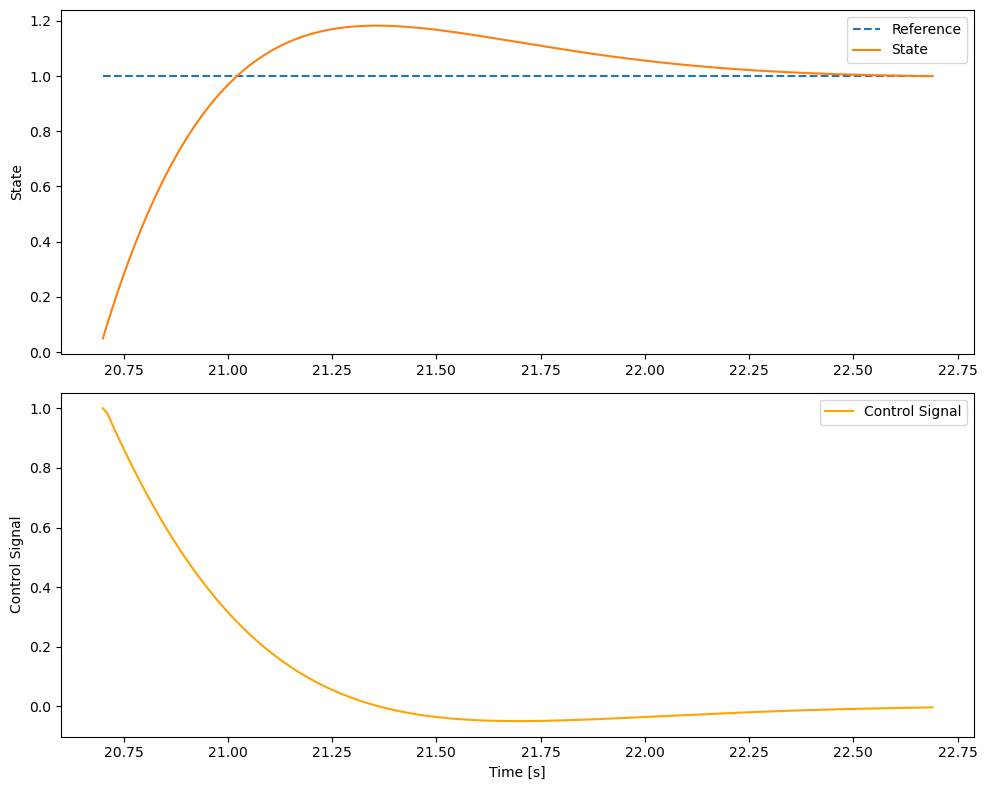

In [104]:
ref = 1
state = 0.0

t_vals = []
ref_vals = []
state_vals = []
u_vals = []

for step in range(200):
    print(f"step: {step}, state: {state:.2f}, control signal: {u:.2f}")
    t_vals.append(t)
    pid.set('ref', ref)
    pid.set('y', state)
    pid.do_step(current_t=t, step_size=dt)
    u = float(pid.get('u')[0])
    state += 5*u*dt
    pid.set('y', state)
    t += dt
    ref_vals.append(ref)
    state_vals.append(state)
    u_vals.append(u)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(t_vals, ref_vals, label='Reference', linestyle='--')
plt.plot(t_vals, state_vals, label='State')
plt.ylabel('State')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t_vals, u_vals, label='Control Signal', color='orange')
plt.xlabel('Time [s]')
plt.ylabel('Control Signal')
plt.legend()
plt.tight_layout()
plt.show()